# 🚀 XGBoost-Based Financial Fraud Detection

## Machine Learning Classification Project

This notebook demonstrates how **XGBoost (Extreme Gradient Boosting)** can be used to detect fraudulent financial transactions.

### 🎯 Objective

The main objective is to build a machine learning model that can classify a transaction as:

- **0 → Legitimate Transaction**
- **1 → Fraudulent Transaction**

### 🧠 Algorithm

We will use **XGBoost Classifier**, a supervised machine learning algorithm based on gradient boosting.

### 📌 What We Will Do

1. Load the dataset
2. Understand the data
3. Clean and prepare the data
4. Explore fraud patterns
5. Separate features and target
6. Encode categorical features
7. Split the data
8. Train an XGBoost model
9. Make predictions
10. Evaluate the model
11. Analyze feature importance
12. Calculate fraud probability and risk score

# 1. 🧠 What is XGBoost?

**XGBoost** stands for **Extreme Gradient Boosting**.

It is a supervised machine learning algorithm that uses multiple decision trees to make predictions.

Instead of creating all trees independently, XGBoost creates them **sequentially**.

Each new tree tries to improve the mistakes made by the previous trees.

### Simple Idea

```text
Training Data
     ↓
Tree 1
     ↓
Find Errors
     ↓
Tree 2
     ↓
Correct Errors
     ↓
Tree 3
     ↓
Correct More Errors
     ↓
Final Prediction


# 2. 🔄 Project Workflow

The complete workflow of this project is:

```text
Financial Transaction Dataset
            ↓
      Data Understanding
            ↓
        Data Cleaning
            ↓
            EDA
            ↓
      Feature Preparation
            ↓
    Categorical Encoding
            ↓
      Train-Test Split
            ↓
      XGBoost Classifier
            ↓
        Model Training
            ↓
         Prediction
            ↓
      Model Evaluation
            ↓
      Feature Importance
            ↓
       Fraud Probability
            ↓
          Risk Score


# 3. 📦 Import Libraries

First, we import the Python libraries required for this project.

### Libraries Used

- **Pandas** → Data loading and manipulation
- **NumPy** → Numerical operations
- **Matplotlib** → Data visualization
- **XGBoost** → Machine learning model
- **Scikit-learn** → Data splitting and model evaluation

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

print("Libraries imported successfully! ✅")

Libraries imported successfully! ✅


# 4. 📂 Load the Dataset

The dataset contains information about financial transactions.

We use the Pandas `read_csv()` function to load the CSV file into a DataFrame.

A **DataFrame** is a table containing rows and columns.

In [35]:
df = pd.read_csv("synthetic_fraud_dataset.csv")
print(df)
print("Dataset loaded successfully! ✅")

      Transaction_ID    User_ID  Transaction_Amount Transaction_Type  \
0          TXN_33553  USER_1834               39.79              POS   
1           TXN_9427  USER_7875                1.19    Bank Transfer   
2            TXN_199  USER_2734               28.96           Online   
3          TXN_12447  USER_2617              254.32   ATM Withdrawal   
4          TXN_39489  USER_2014               31.28              POS   
...              ...        ...                 ...              ...   
49995      TXN_11284  USER_4796               45.05           Online   
49996      TXN_44732  USER_1171              126.15              POS   
49997      TXN_38158  USER_2510               72.02           Online   
49998        TXN_860  USER_2248               64.89    Bank Transfer   
49999      TXN_15795  USER_6529               13.00    Bank Transfer   

                 Timestamp  Account_Balance Device_Type  Location  \
0      2023-08-14 19:30:00         93213.17      Laptop    Sydney 

# 5. 🔎 Understand the Dataset

Before training a machine learning model, it is important to understand the data.

We will check:

- First few rows
- Number of rows and columns
- Column names
- Data types
- Missing values
- Duplicate rows
- Statistical information

In [36]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [37]:
print("Number of Rows   :", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows   : 50000
Number of Columns: 21


In [38]:
print("Column Names:\n")

for column in df.columns:
    print(column)

Column Names:

Transaction_ID
User_ID
Transaction_Amount
Transaction_Type
Timestamp
Account_Balance
Device_Type
Location
Merchant_Category
IP_Address_Flag
Previous_Fraudulent_Activity
Daily_Transaction_Count
Avg_Transaction_Amount_7d
Failed_Transaction_Count_7d
Card_Type
Card_Age
Transaction_Distance
Authentication_Method
Risk_Score
Is_Weekend
Fraud_Label


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  str    
 1   User_ID                       50000 non-null  str    
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  str    
 4   Timestamp                     50000 non-null  str    
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  str    
 7   Location                      50000 non-null  str    
 8   Merchant_Category             50000 non-null  str    
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  Failed_Trans

# 6. 🧹 Data Cleaning

Clean data is important for building a reliable machine learning model.

We will check for:

### Missing Values

Missing values mean some information is unavailable.

### Duplicate Rows

Duplicate rows mean the same information appears more than once.

In [40]:
print("missing values:")
print(df.isnull().sum())
print("\nTotal Missing Values:", df.isnull().sum().sum())

missing values:
Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64

Total Missing Values: 0


In [41]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


# 7. 📊 Statistical Summary

The `describe()` function provides basic statistics about numerical features.

It shows:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

This helps us understand the distribution and range of numerical values.

In [42]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Transaction_Amount,50000.0,99.411012,98.687292,0.0000,28.6775,69.66000,138.852500,1174.14
Account_Balance,50000.0,50294.065981,28760.458557,500.4800,25355.9950,50384.43000,75115.135000,99998.31
IP_Address_Flag,50000.0,0.050200,0.218360,0.0000,0.0000,0.00000,0.000000,1.00
Previous_Fraudulent_Activity,50000.0,0.098400,0.297858,0.0000,0.0000,0.00000,0.000000,1.00
Daily_Transaction_Count,50000.0,7.485240,4.039637,1.0000,4.0000,7.00000,11.000000,14.00
Avg_Transaction_Amount_7d,50000.0,255.271924,141.382279,10.0000,132.0875,256.08500,378.032500,500.00
Failed_Transaction_Count_7d,50000.0,2.003540,1.414273,0.0000,1.0000,2.00000,3.000000,4.00
Card_Age,50000.0,119.999940,68.985817,1.0000,60.0000,120.00000,180.000000,239.00
Transaction_Distance,50000.0,2499.164155,1442.013834,0.2500,1256.4975,2490.78500,3746.395000,4999.93
Risk_Score,50000.0,0.501556,0.287774,0.0001,0.2540,0.50225,0.749525,1.00


# 8. 🎯 Target Variable

The variable we want the machine learning model to predict is called the **target variable**.

In this dataset, our target is:

`Fraud_Label`

### Meaning

- **0 → Legitimate Transaction**
- **1 → Fraudulent Transaction**

We will check how many transactions belong to each class.

In [43]:
fraud_counts = df["Fraud_Label"].value_counts().sort_index()

print("Legitimate Transactions:", fraud_counts.get(0, 0))
print("Fraudulent Transactions:", fraud_counts.get(1, 0))

Legitimate Transactions: 33933
Fraudulent Transactions: 16067


In [44]:
fraud_percentage = (
    df["Fraud_Label"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Class Distribution (%)")
print(fraud_percentage)

Class Distribution (%)
Fraud_Label
0    67.866
1    32.134
Name: proportion, dtype: float64


# 9. 📊 Fraud Distribution

We will visualize the number of legitimate and fraudulent transactions.

This is important because fraud datasets can be **imbalanced**.

For example:

```text
Legitimate → 95%
Fraud      → 5%


## Cell 22 — Code

```python
fraud_counts.plot(kind="bar")

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"],
    rotation=0
)

plt.show()

# 10. 💰 Transaction Amount Analysis

Transaction amount may contain useful information for detecting fraud.

We will compare the average transaction amount for:

- Legitimate transactions
- Fraudulent transactions

In [45]:
df.groupby("Fraud_Label")["Transaction_Amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Fraud_Label,,,,,
0,33933,99.281907,69.40,0.01,1174.14
1,16067,99.683678,70.12,0.00,1005.32


# 11. ⏰ Timestamp Feature Engineering

The dataset contains a `Timestamp` column.

A raw timestamp is not very useful directly.

Instead, we can extract useful information such as:

- Transaction hour
- Day of week
- Month

Fraud patterns may change depending on when a transaction occurs.

In [46]:
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce"
)

df["Transaction_Hour"] = df["Timestamp"].dt.hour
df["Transaction_DayOfWeek"] = df["Timestamp"].dt.dayofweek
df["Transaction_Month"] = df["Timestamp"].dt.month

df[
    [
        "Timestamp",
        "Transaction_Hour",
        "Transaction_DayOfWeek",
        "Transaction_Month"
    ]
].head()

,Timestamp,Transaction_Hour,Transaction_DayOfWeek,Transaction_Month
0,2023-08-14 19:30:00,19,0,8
1,2023-06-07 04:01:00,4,2,6
2,2023-06-20 15:25:00,15,1,6
3,2023-12-07 00:31:00,0,3,12
4,2023-11-11 23:44:00,23,5,11


# 12. 🎯 Separate Features and Target

Machine learning requires two main parts:

## Features (X)

These are the input variables used to make predictions.

Examples:

- Transaction amount
- Account balance
- Device type
- Transaction distance

## Target (y)

This is the value we want to predict.

In this project:

`Fraud_Label`

Therefore:

```text
Transaction Features (X)
          ↓
       XGBoost
          ↓
Fraud Prediction (y)

In [47]:
X = df.drop(
    columns=[
        "Fraud_Label",
        "Transaction_ID",
        "User_ID",
        "Timestamp"
    ]
)

y = df["Fraud_Label"]

print("Features shape:", X.shape)
print("Target shape  :", y.shape)

Features shape: (50000, 20)
Target shape  : (50000,)


# 13. 🔤 Convert Categorical Data into Numbers

Some columns contain text values.

For example:

```text
Device Type:
Mobile
Laptop
Tablet

In [48]:
categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns

print("Categorical Columns:")
print(list(categorical_columns))

Categorical Columns:
['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']


C:\Users\omkar\AppData\Local\Temp\ipykernel_18316\3912087271.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [49]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Data successfully encoded! ✅")
print("Total Features:", X.shape[1])

Data successfully encoded! ✅
Total Features: 33


# 14. 🔍 Check Prepared Data

Before training the model, we verify that the data is ready.

The model features should now be numerical and should not contain missing values.

In [50]:
print("Remaining Missing Values:", X.isnull().sum().sum())

print("\nData Types:")
print(X.dtypes.value_counts())

Remaining Missing Values: 0

Data Types:
bool       19
int64       6
float64     5
int32       3
Name: count, dtype: int64


# 15. ✂️ Train-Test Split

We divide our dataset into two parts.

### 🏋️ Training Set — 80%

Used to teach the model.

### 🧪 Testing Set — 20%

Used to evaluate the model on data it has never seen before.

We also use:

`stratify=y`

This helps maintain the same fraud distribution in both training and testing datasets.

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("\nTraining Labels:", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features: (40000, 33)
Testing Features : (10000, 33)

Training Labels: (40000,)
Testing Labels : (10000,)


# 16. 🌳 Create the XGBoost Model

We will use `XGBClassifier` because our problem is a **classification problem**.

Our model needs to predict:

```text
0 → Legitimate
1 → Fraud

## ⚙️ Important XGBoost Parameters

XGBoost provides several important parameters that control how the model learns and performs.

### 🌳 1. `n_estimators`

Specifies the **number of decision trees** created by XGBoost.

For example, `n_estimators=200` means the model will build 200 trees.

- Higher value → More trees and more learning
- Too high → Can increase training time and overfitting

### 📈 2. `learning_rate`

Controls how much each new tree contributes to the final prediction.

For example, `learning_rate=0.05` means each new tree makes a relatively small contribution.

- Smaller value → Slower learning
- Larger value → Faster learning
- Smaller learning rates usually require more trees

### 🌲 3. `max_depth`

Controls the **maximum depth** of each decision tree.

For example, `max_depth=5` allows each tree to grow up to a maximum depth of 5.

- Higher value → More complex trees
- Lower value → Simpler trees
- Very high values → Higher risk of overfitting

### 🎲 4. `subsample`

Controls the percentage of training data used for each tree.

For example, `subsample=0.8` means approximately **80% of the training samples** are used for each tree.

Using a value below `1.0` can help reduce overfitting.

### 🧩 5. `colsample_bytree`

Controls the percentage of features used by each tree.

For example, `colsample_bytree=0.8` means approximately **80% of the available features** are used for each tree.

This can help reduce overfitting and make the trees more diverse.

### 🎯 6. `random_state`

Controls the randomness used by the model.

For example, `random_state=42` makes the results more reproducible.

The value `42` is simply a commonly used random seed.

### 📊 7. `eval_metric`

Specifies the metric used to evaluate the model during training.

For example, `eval_metric="logloss"` uses **Log Loss** to evaluate the model's predictions.

Lower log loss generally indicates better probability predictions.

## 🧠 Quick Summary

| Parameter | Purpose |
|---|---|
| `n_estimators` | Number of decision trees |
| `learning_rate` | How much each tree contributes |
| `max_depth` | Maximum depth of each tree |
| `subsample` | Percentage of training data used per tree |
| `colsample_bytree` | Percentage of features used per tree |
| `random_state` | Makes results reproducible |
| `eval_metric` | Measures model performance during training |

### 🔑 Easy Way to Remember

- `n_estimators` → How many trees?
- `learning_rate` → How fast does the model learn?
- `max_depth` → How deep are the trees?
- `subsample` → How much data per tree?
- `colsample_bytree` → How many features per tree?
- `random_state` → Can we reproduce the result?
- `eval_metric` → How do we measure performance?

In [53]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

print("XGBoost model created successfully! 🚀")

XGBoost model created successfully! 🚀


# 17. 🏋️ Train the Model

Now we train XGBoost using the training dataset.

The `fit()` function allows the model to learn patterns between transaction features and fraud labels.

During training:

```text
Tree 1
   ↓
Makes Predictions
   ↓
Calculate Errors
   ↓
Tree 2
   ↓
Improve Previous Errors
   ↓
Tree 3
   ↓
Improve Again
   ↓
...
   ↓
Final XGBoost Model

In [54]:
model.fit(
    X_train,
    y_train
)

print("Model training completed! ✅")

Model training completed! ✅


# 18. 🔮 Make Predictions

Now the model has learned from the training dataset.

We give the model the unseen testing data.

The model predicts:

- `0` → Legitimate
- `1` → Fraud

In [55]:
y_pred = model.predict(X_test)

print("First 20 Predictions:")
print(y_pred[:20])

First 20 Predictions:
[0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1]


# 19. 🎲 Fraud Probability

XGBoost can also calculate the probability that a transaction is fraudulent.

For example:

```text
Fraud Probability = 0.10

In [56]:
fraud_probability = model.predict_proba(
    X_test
)[:, 1]

print("First 10 Fraud Probabilities:")

print(fraud_probability[:10])

First 10 Fraud Probabilities:
[2.3194501e-04 2.1624097e-04 2.4113897e-04 2.4574666e-04 2.7271124e-04
 2.8188541e-04 9.9942541e-01 2.6583410e-04 2.3749644e-04 2.6711458e-04]


# 20. 📊 Evaluate the Model

We should not judge a fraud detection model using only accuracy.

We will calculate:

### Accuracy

How many total predictions were correct?

### Precision

When the model predicts fraud, how often is it correct?

### Recall

Out of all actual fraud cases, how many did the model detect?

### F1-Score

Balances precision and recall.

### ROC-AUC

Measures how well the model separates fraudulent and legitimate transactions.

In [57]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    fraud_probability
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Accuracy  : 0.9991
Precision : 0.9984
Recall    : 0.9988
F1-Score  : 0.9986
ROC-AUC   : 1.0000


# 21. 📋 Classification Report

The classification report gives detailed performance information for both classes.

The most important values are:

- Precision
- Recall
- F1-score

For fraud detection, pay special attention to the **Fraud Recall**.

A low fraud recall means the model is missing many fraudulent transactions.

In [58]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      6787
       Fraud       1.00      1.00      1.00      3213

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



# 22. 🔲 Confusion Matrix

The confusion matrix helps us understand the model's mistakes.

### True Negative (TN)

Legitimate transaction correctly predicted as legitimate.

### False Positive (FP)

Legitimate transaction incorrectly predicted as fraud.

### False Negative (FN)

Fraudulent transaction incorrectly predicted as legitimate.

### True Positive (TP)

Fraudulent transaction correctly detected as fraud.

For fraud detection, **False Negatives are especially important** because they represent fraud that the model failed to detect.

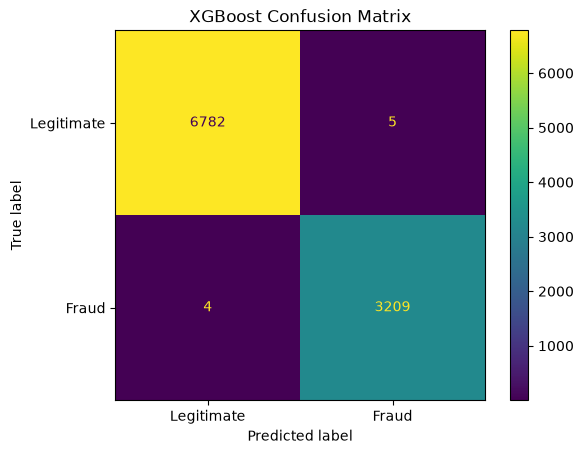

In [59]:
cm = confusion_matrix(
    y_test,
    y_pred
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Legitimate",
        "Fraud"
    ]
)

display.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

# 23. 📈 ROC Curve

The ROC curve shows how the classifier performs at different probability thresholds.

It compares:

- **True Positive Rate**
- **False Positive Rate**

The ROC-AUC score summarizes the model's ability to separate the two classes.

A higher ROC-AUC generally indicates better class separation.

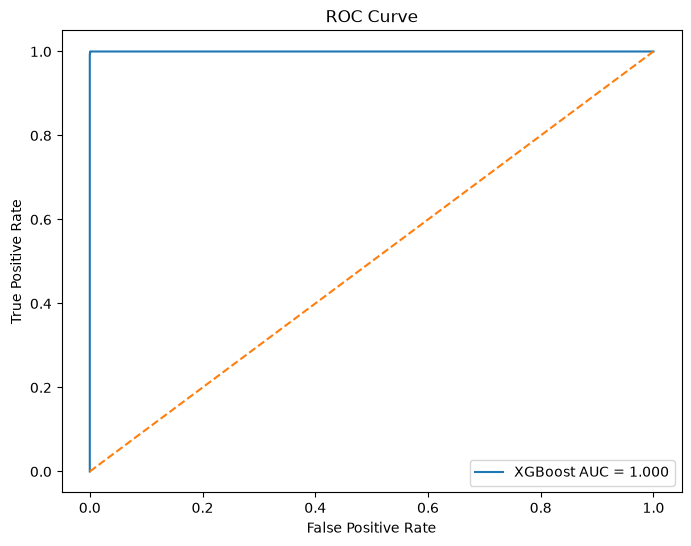

In [60]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    fraud_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

# 24. 🔍 Feature Importance

Feature importance helps us understand which features were most useful to the XGBoost model.

For example, the model may consider features such as:

- Transaction amount
- Risk score
- Transaction distance
- Previous fraudulent activity
- Failed transaction count

A larger importance value means the feature had more influence on the model's tree-building process.

Feature importance gives a **global view** of the model.

It does not completely explain why one specific transaction received a particular prediction.

In [61]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
6,Failed_Transaction_Count_7d,0.622614
9,Risk_Score,0.354410
19,Location_Mumbai,0.001194
31,Authentication_Method_PIN,0.001154
18,Device_Type_Tablet,0.001153
10,Is_Weekend,0.001073
26,Merchant_Category_Travel,0.000996
21,Location_Sydney,0.000977
1,Account_Balance,0.000961
32,Authentication_Method_Password,0.000946


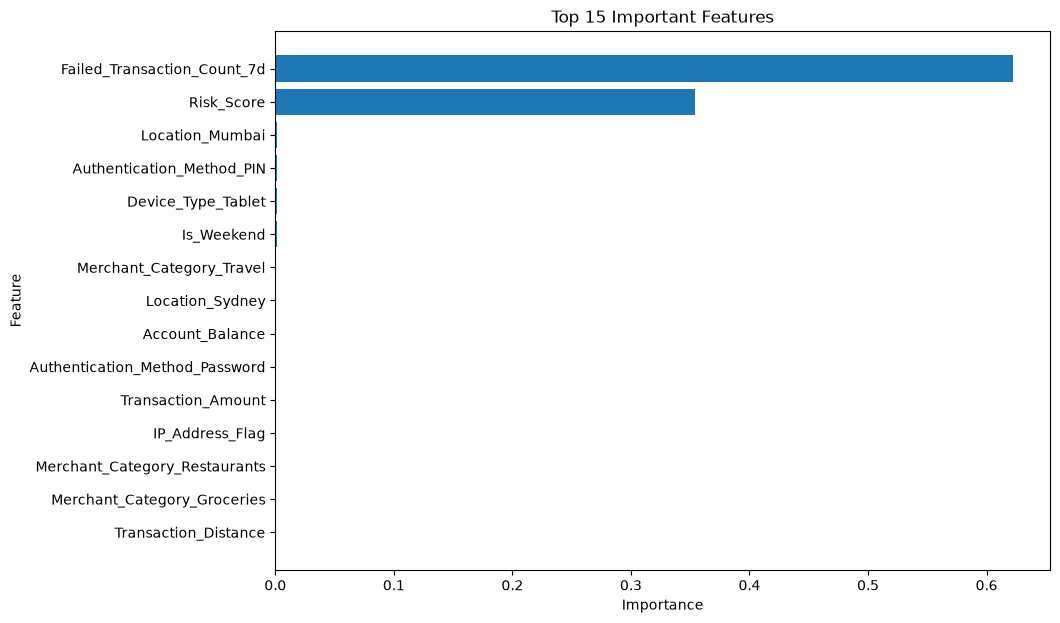

In [62]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

# 25. 🎯 Fraud Risk Score

The model provides a fraud probability between `0` and `1`.

For this project, we can convert this probability into a simple score between `0` and `100`.

Formula:

\[
Risk\ Score = Fraud\ Probability \times 100
\]

Example:

```text
Fraud Probability = 0.87

Risk Score = 0.87 × 100

Risk Score = 87

In [64]:
risk_score = fraud_probability * 100


def get_risk_level(score):
    if score <= 30:
        return "Low"
    elif score <= 70:
        return "Medium"
    else:
        return "High"


risk_levels = [
    get_risk_level(score)
    for score in risk_score
]

# 26. 📋 Final Prediction Results

Now we combine the model outputs into a simple table.

The table contains:

- Actual fraud label
- Model prediction
- Fraud probability
- Risk score
- Risk level

This makes the model output easier to understand.

In [65]:
results = pd.DataFrame({
    "Actual_Label": y_test.values,
    "Predicted_Label": y_pred,
    "Fraud_Probability": fraud_probability,
    "Risk_Score": risk_score,
    "Risk_Level": risk_levels
})

results.head(20)

,Actual_Label,Predicted_Label,Fraud_Probability,Risk_Score,Risk_Level
0,0,0,0.000232,0.023195,Low
1,0,0,0.000216,0.021624,Low
2,0,0,0.000241,0.024114,Low
3,0,0,0.000246,0.024575,Low
4,0,0,0.000273,0.027271,Low
5,0,0,0.000282,0.028189,Low
6,1,1,0.999425,99.942543,High
7,0,0,0.000266,0.026583,Low
8,0,0,0.000237,0.023750,Low
9,0,0,0.000267,0.026711,Low


# 27. 🚨 High-Risk Transactions

We can filter transactions that have a high predicted fraud probability.

For this demonstration, we consider:

```text
Fraud Probability ≥ 0.80

In [66]:
high_risk = results[
    results["Fraud_Probability"] >= 0.80
]

print(
    "Number of High-Risk Transactions:",
    len(high_risk)
)

high_risk.head(20)

Number of High-Risk Transactions: 3198


,Actual_Label,Predicted_Label,Fraud_Probability,Risk_Score,Risk_Level
6,1,1,0.999425,99.942543,High
13,1,1,0.999436,99.943642,High
19,1,1,0.999444,99.944405,High
20,1,1,0.999351,99.935074,High
21,1,1,0.999407,99.940720,High
22,1,1,0.999344,99.934402,High
25,1,1,0.999444,99.944397,High
27,1,1,0.999397,99.939690,High
28,1,1,0.999414,99.941360,High
29,1,1,0.999939,99.993919,High


# 28. 🧠 How the Complete System Works

Let's understand the entire project in simple terms.

### Step 1 — Dataset

We start with historical financial transactions.

### Step 2 — Data Preparation

We clean the dataset and convert text information into numerical information.

### Step 3 — Training

We give XGBoost:

```text
Transaction Information + Correct Fraud Label
```

The model learns patterns associated with fraud.

### Step 4 — Testing

We give the trained model transactions it has never seen before.

### Step 5 — Prediction

The model predicts:

```text
0 → Legitimate
1 → Fraud
```

### Step 6 — Probability

The model calculates how likely the transaction is to be fraudulent.

### Step 7 — Risk Score

We convert the probability into an easy-to-understand score.

---

## Complete Flow

```text
Financial Transaction
        ↓
Data Cleaning
        ↓
Feature Engineering
        ↓
Categorical Encoding
        ↓
Train/Test Split
        ↓
XGBoost
        ↓
Fraud Prediction
        ↓
Fraud Probability
        ↓
Risk Score
        ↓
Risk Level
```


# 🏆 Conclusion

In this notebook, we built a **Financial Fraud Detection System using XGBoost**.

## What We Learned

### 1. XGBoost

XGBoost is a **supervised machine learning algorithm** based on gradient boosting.

### 2. Data Preparation

We:

- Loaded the dataset
- Explored the data
- Checked missing values
- Checked duplicates
- Analyzed fraud distribution
- Created time-based features
- Converted categorical data into numerical data

### 3. Model Training

We divided the data into training and testing sets.

Then we trained an `XGBClassifier`.

### 4. Model Evaluation

We evaluated the model using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC

### 5. Feature Importance

We identified the features that were most useful to the XGBoost model.

### 6. Risk Scoring

We converted fraud probabilities into easy-to-understand risk scores.

---

## Final Architecture

```text
                    Dataset
                       ↓
               Data Preparation
                       ↓
               Feature Engineering
                       ↓
                Train/Test Split
                       ↓
                  XGBoost
                       ↓
              Fraud Prediction
                       ↓
             Fraud Probability
                       ↓
                  Risk Score